# Correlación de Pearson: Visitas vs. Monto del Pedido

## 1. Contexto

El equipo de LMB observó que, en los meses con más quejas de clientes, también aumentan las devoluciones de producto. Concluyeron apresuradamente que **"las quejas causan las devoluciones"**. Sin embargo, ambas variables podrían estar siendo causadas por una **tercera variable** (variable de confusión): la calidad del producto entregado ese mes.

- Si la calidad baja → suben las quejas.
- Si la calidad baja → suben las devoluciones.
- Quejas y devoluciones se mueven juntas, pero **ninguna causa la otra directamente**.

Esto se conoce como **correlación espuria**: dos variables parecen relacionadas porque comparten una causa común, no porque exista una relación causal directa entre ellas.

Para reforzar el concepto de correlación (sin entrar en causalidad), se analiza a continuación un segundo caso: la relación entre las **visitas mensuales a un comercio** y el **monto del pedido**.

## 2. Tabla de interpretación del coeficiente r

| Valor de r | Interpretación |
|---|---|
| r = 1 | Correlación positiva perfecta: cuando una variable sube, la otra sube en la misma proporción |
| 0.7 a 0.99 | Correlación positiva fuerte |
| 0.3 a 0.69 | Correlación positiva moderada |
| 0.01 a 0.29 | Correlación positiva débil |
| 0 | No hay correlación lineal |
| -0.01 a -0.29 | Correlación negativa débil |
| -0.3 a -0.69 | Correlación negativa moderada |
| -0.7 a -0.99 | Correlación negativa fuerte |
| r = -1 | Correlación negativa perfecta: cuando una variable sube, la otra baja en la misma proporción |

## 3. Datos del caso: Visitas (X) vs. Monto del pedido en miles (Y)

| Comercio | Visitas en el mes (X) | Monto del pedido, en miles (Y) |
|---|---|---|
| A | 2 | 45 |
| B | 4 | 68 |
| C | 1 | 30 |
| D | 6 | 95 |
| E | 3 | 52 |
| F | 5 | 80 |
| G | 2 | 40 |

## 4. Fórmula del coeficiente de correlación de Pearson

$$r = \frac{n\sum XY - \sum X \sum Y}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$$

## 5. Desarrollo en Python

### 5.1 Carga de datos y construcción de la tabla auxiliar

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos originales
data = {
    'Comercio': ['MaxiPali', 'PriceSmart', 'MasxMenos', 'MegaSuper', 'Pali', 'Fesh Market', 'Cooperativas'],
    'X': [2, 4, 1, 6, 3, 5, 2],
    'Y': [45, 68, 30, 95, 52, 80, 40]
}

df = pd.DataFrame(data)

# Columnas auxiliares requeridas por la fórmula de Pearson
df['XY'] = df['X'] * df['Y']
df['X2'] = df['X'] ** 2
df['Y2'] = df['Y'] ** 2

df

,Comercio,X,Y,XY,X2,Y2
0,MaxiPali,2,45,90,4,2025
1,PriceSmart,4,68,272,16,4624
2,MasxMenos,1,30,30,1,900
3,MegaSuper,6,95,570,36,9025
4,Pali,3,52,156,9,2704
5,Fesh Market,5,80,400,25,6400
6,Cooperativas,2,40,80,4,1600


In [12]:
# Fila de sumatorias
sumatorias = df[['X', 'Y', 'XY', 'X2', 'Y2']].sum()
print('Sumatorias:')
print(sumatorias)

Sumatorias:
X        23
Y       410
XY     1598
X2       95
Y2    27278
dtype: int64


### 5.2 Cálculo manual de r (aplicando la fórmula paso a paso)

In [3]:
n = len(df)
sum_x = df['X'].sum()
sum_y = df['Y'].sum()
sum_xy = df['XY'].sum()
sum_x2 = df['X2'].sum()
sum_y2 = df['Y2'].sum()

numerador = n * sum_xy - sum_x * sum_y
denominador = np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))

r_manual = numerador / denominador

print(f'n = {n}')
print(f'ΣX = {sum_x}, ΣY = {sum_y}, ΣXY = {sum_xy}, ΣX² = {sum_x2}, ΣY² = {sum_y2}')
print(f'Numerador = {numerador}')
print(f'Denominador = {denominador:.4f}')
print(f'r (cálculo manual) = {r_manual:.4f}')

n = 7
ΣX = 23, ΣY = 410, ΣXY = 1598, ΣX² = 95, ΣY² = 27278
Numerador = 1756
Denominador = 1762.6843
r (cálculo manual) = 0.9962


### 5.3 Verificación con funciones de librerías (pandas y numpy)

In [13]:
# Verificación con pandas
r_pandas = df['X'].corr(df['Y'])

# Verificación con numpy
r_numpy = np.corrcoef(df['X'], df['Y'])[0, 1]

print(f'r (pandas)  = {r_pandas:.4f}')
print(f'r (numpy)   = {r_numpy:.4f}')
print(f'r (manual)  = {r_manual:.4f}')

r (pandas)  = 0.9962
r (numpy)   = 0.9962
r (manual)  = 0.9962


### 5.4 Gráfico de dispersión con línea de tendencia

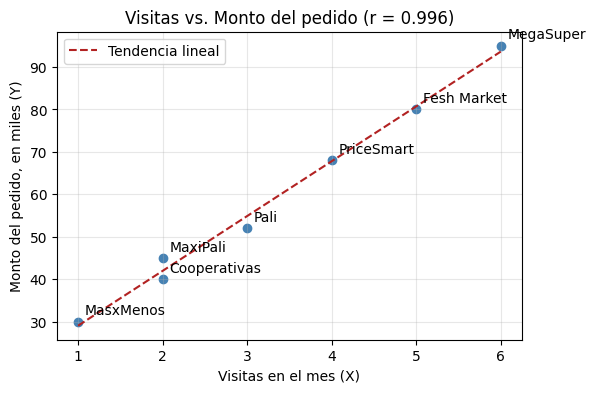

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['Y'], color='steelblue')
for _, row in df.iterrows():
    plt.annotate(row['Comercio'], (row['X'], row['Y']), textcoords='offset points', xytext=(5, 5))

# Línea de tendencia
z = np.polyfit(df['X'], df['Y'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['X'].min(), df['X'].max(), 100)
plt.plot(x_line, p(x_line), color='firebrick', linestyle='--', label='Tendencia lineal')

plt.title(f'Visitas vs. Monto del pedido (r = {r_manual:.3f})')
plt.xlabel('Visitas en el mes (X)')
plt.ylabel('Monto del pedido, en miles (Y)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

r = 0.996


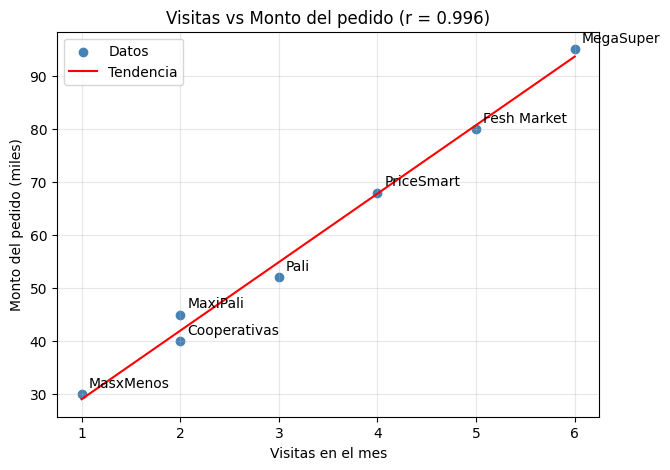

In [19]:
import numpy as np
import matplotlib.pyplot as plt

comercios = ['MaxiPali', 'PriceSmart', 'MasxMenos', 'MegaSuper', 'Pali', 'Fesh Market', 'Cooperativas']
visitas = [2, 4, 1, 6, 3, 5, 2]
monto = [45, 68, 30, 95, 52, 80, 40]

r = np.corrcoef(visitas, monto)[0, 1]
print(f"r = {r:.3f}")

pendiente, intercepto = np.polyfit(visitas, monto, 1)
x_linea = np.linspace(min(visitas), max(visitas), 100)
linea = pendiente * x_linea + intercepto

plt.figure(figsize=(7, 5))
plt.scatter(visitas, monto, label="Datos", color="steelblue")

for c, x, y in zip(comercios, visitas, monto):
    plt.annotate(c, (x, y), textcoords="offset points", xytext=(5, 5))

plt.plot(x_linea, linea, color="red", label="Tendencia")  # ahora sí usa la línea real
plt.title(f"Visitas vs Monto del pedido (r = {r:.3f})")
plt.xlabel("Visitas en el mes")
plt.ylabel("Monto del pedido (miles)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.5 Gráfico de líneas por Comercio (X y Y), con etiquetas de valor

Mismos datos, presentados como serie por comercio (eje X = comercio) para comparar visitas y monto del pedido, siguiendo el mismo estilo de `annotate` usado en el análisis de ventas por mes.

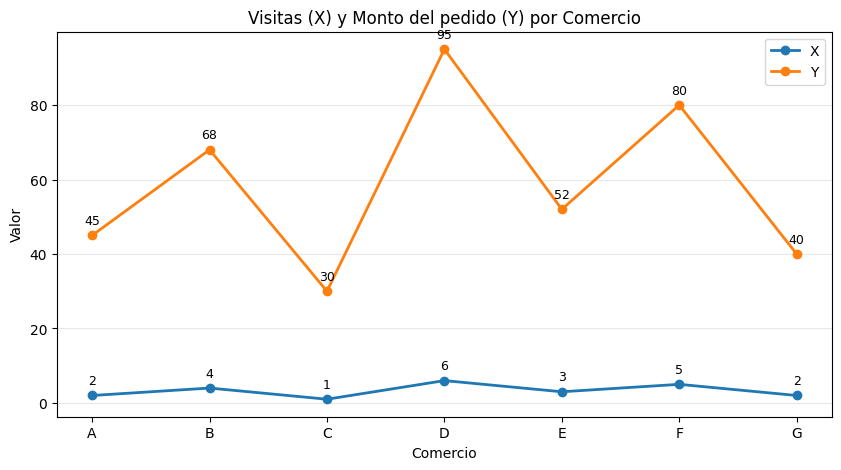

In [6]:
df_lineas = df.set_index('Comercio')[['X', 'Y']]

ax = df_lineas.plot(
    kind='line',
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Visitas (X) y Monto del pedido (Y) por Comercio')
plt.xlabel('Comercio')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Etiquetas con el valor de cada punto
for columna in df_lineas.columns:
    for i, valor in enumerate(df_lineas[columna]):
        ax.annotate(str(valor), (i, valor), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)

plt.show()

### 5.6 Gráfico de barras agrupadas por Comercio, con `bar_label`

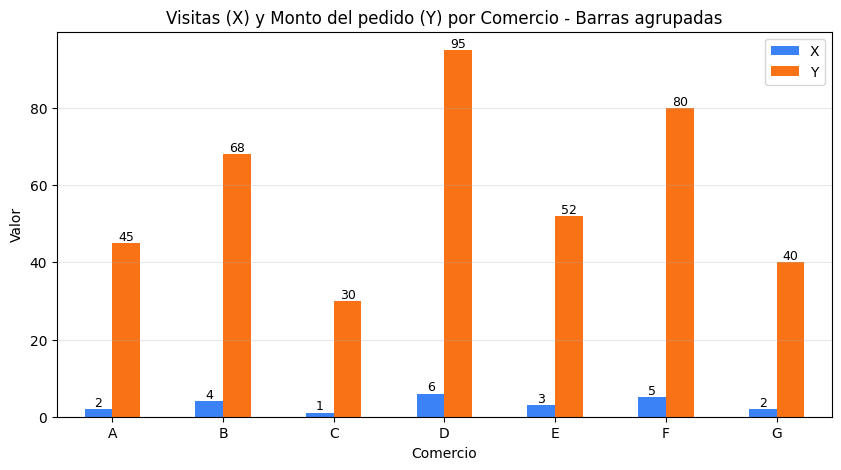

In [7]:
ax2 = df_lineas.plot(
    kind='bar',
    figsize=(10, 5),
    color=['#3B82F6', '#F97316']
)

plt.title('Visitas (X) y Monto del pedido (Y) por Comercio - Barras agrupadas')
plt.xlabel('Comercio')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Etiquetas con el valor de cada barra
for contenedor in ax2.containers:
    ax2.bar_label(contenedor, fontsize=9)

plt.show()

### 5.7 Visitas y Monto en un mismo gráfico con doble eje

Igual que en tu ejemplo (ventas + porcentaje en doble eje): aquí se combinan Visitas (eje izquierdo) y Monto del pedido (eje derecho) para ver ambas escalas en un solo gráfico.

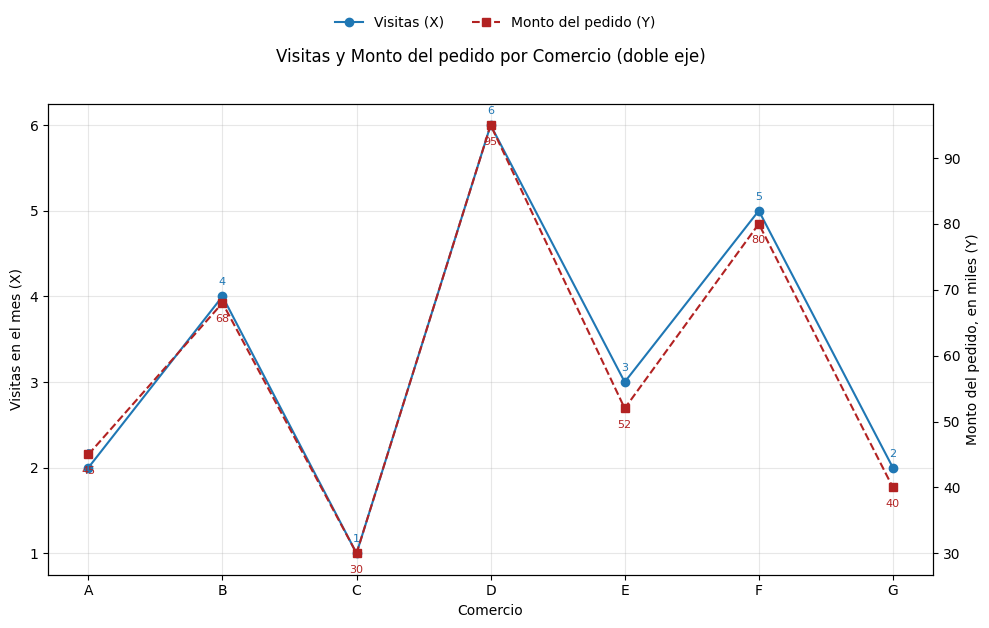

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

df_lineas['X'].plot(
    kind='line', marker='o', ax=ax1, color='#1f77b4', label='Visitas (X)'
)
ax1.set_ylabel('Visitas en el mes (X)')
ax1.set_xlabel('Comercio')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
df_lineas['Y'].plot(
    kind='line', marker='s', linestyle='--', ax=ax2, color='firebrick', label='Monto del pedido (Y)'
)
ax2.set_ylabel('Monto del pedido, en miles (Y)')

# Etiquetas de valor en cada punto
for i, y in enumerate(df_lineas['X']):
    ax1.annotate(f'{y}', (i, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color='#1f77b4')

for i, y in enumerate(df_lineas['Y']):
    ax2.annotate(f'{y}', (i, y), textcoords='offset points', xytext=(0, -14),
                 ha='center', fontsize=8, color='firebrick')

# Leyenda única, fuera del área de trazado
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if ax1.get_legend(): ax1.get_legend().remove()
if ax2.get_legend(): ax2.get_legend().remove()

fig.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=2, frameon=False)

plt.title('Visitas y Monto del pedido por Comercio (doble eje)', pad=30)
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

### 5.8 Gráfico circular (pastel) de la distribución del Monto del pedido por Comercio

Usando la sintaxis proporcionada, adaptada a los nombres de columnas de este DataFrame (`Y` = Monto del pedido).

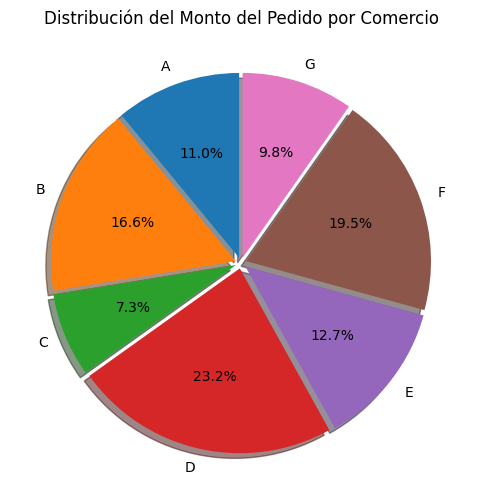

In [9]:
plt.figure(figsize=(6, 6))
plt.pie(
    df["Y"],
    labels=df["Comercio"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03] * len(df),
    shadow=True
)
plt.title("Distribución del Monto del Pedido por Comercio")
plt.show()

## 6. Interpretación de resultados

El coeficiente obtenido es **r ≈ 0.996**, lo cual, según la tabla de interpretación, corresponde a una **correlación positiva fuerte** (rango 0.7 a 0.99, muy cercana a la correlación perfecta).

Esto indica que, a mayor número de visitas mensuales a un comercio, mayor tiende a ser el monto del pedido, con muy poca dispersión respecto a esa tendencia lineal. Las gráficas de líneas y barras por comercio muestran cómo ambas variables suben de forma paralela (D y F, con más visitas, tienen también los montos más altos; C, con solo 1 visita, tiene el monto más bajo).

**Nota importante — correlación no implica causalidad:** al igual que en el caso de LMB (quejas y devoluciones), un valor de r alto solo confirma la fuerza y dirección de la relación lineal entre las variables, no prueba por sí solo una relación causa-efecto. En este caso el vínculo causal es razonable desde el punto de vista de negocio (más visitas generan más oportunidades de compra), pero estadísticamente debe evaluarse con cautela, considerando siempre la posibilidad de variables de confusión.